In [1]:
# CELL 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import sqlite3
import os

DB_PATH = "../data/patents.db"
VISUALS_DIR = "../visuals/"
REPORTS_DIR = "../reports/"

conn = sqlite3.connect(DB_PATH)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# CELL 2 - Load Data from Database
df_inventors = pd.read_sql("SELECT * FROM inventors", conn)
df_patents = pd.read_sql("SELECT * FROM patents", conn)

print(f"Patents loaded:   {len(df_patents):,} rows")
print(f"Inventors loaded: {len(df_inventors):,} rows")

Patents loaded:   9,454,161 rows
Inventors loaded: 24,035,276 rows


In [3]:
# CELL 3 - Prepare Data for ML
# count patents per inventor
df_inv_counts = df_inventors.groupby('inventor_id')['patent_id'].count().reset_index()
df_inv_counts.columns = ['inventor_id', 'patent_count']

# add inventor details
df_inv_counts = df_inv_counts.merge(
    df_inventors[['inventor_id','full_name','country']].drop_duplicates('inventor_id'),
    on='inventor_id',
    how='left'
)

print(f"Inventor counts prepared: {len(df_inv_counts):,} rows")
print(df_inv_counts.head())

Inventor counts prepared: 4,294,034 rows
                 inventor_id  patent_count           full_name country
0  0000n8nqsxhrztn7djlxou00k             1        Muamer Zukic      US
1  0004z0eq002iqz3t9ecx7l5ml             1        Paul Barberi      FR
2  000c0a89h3umx2083c1fhf6sc             1  Arthur R. Stennett      US
3  000f0k6brgval6kr9agzjlgcg             1   Lynda M. Salvetti      US
4  000f3mi5t5lpa1ch45ncsfqtz             1     Semion H. Mazor      IL


In [4]:
# CELL 4 - Create Productivity Categories
def categorize(count):
    if count >= 10:
        return 2   # High
    elif count >= 3:
        return 1   # Medium
    else:
        return 0   # Low

df_inv_counts['productivity'] = df_inv_counts['patent_count'].apply(categorize)
df_inv_counts['productivity_label'] = df_inv_counts['productivity'].map({
    0: 'Low',
    1: 'Medium',
    2: 'High'
})

print("Productivity distribution:")
print(df_inv_counts['productivity_label'].value_counts())

Productivity distribution:
productivity_label
Low       2553394
Medium    1194131
High       546509
Name: count, dtype: int64


In [5]:
# CELL 5 - Train Linear Regression Model
# feature: patent count
# target: productivity category
X = df_inv_counts[['patent_count']]
y = df_inv_counts['productivity']

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)
y_pred_rounded = np.round(y_pred).clip(0, 2).astype(int)

print(f"Training samples:  {len(X_train):,}")
print(f"Testing samples:   {len(X_test):,}")
print(f"R2 Score:          {r2_score(y_test, y_pred):.4f}")
print(f"Mean Abs Error:    {mean_absolute_error(y_test, y_pred):.4f}")

Training samples:  3,435,227
Testing samples:   858,807
R2 Score:          0.1951
Mean Abs Error:    0.5499


C:\Users\5roy\AppData\Local\Temp\ipykernel_6824\828985899.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\5roy\AppData\Local\Temp\ipykernel_6824\828985899.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(VISUALS_DIR + "ml_productivity.png", dpi=150)
c:\Users\5roy\Desktop\patent-pipeline\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


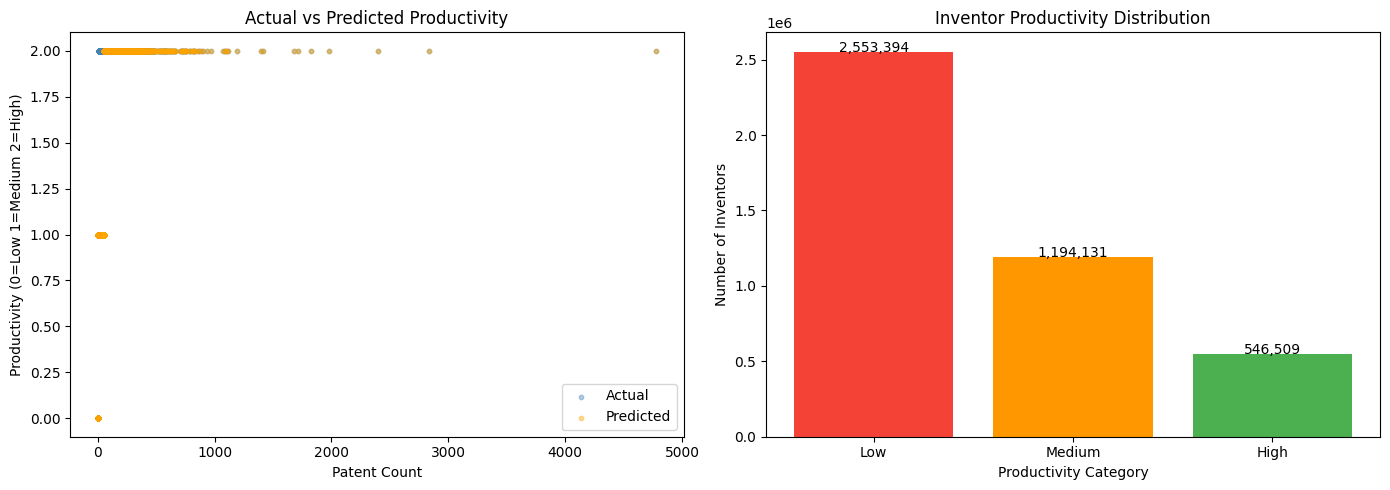

Chart saved: ml_productivity.png


In [6]:
# CELL 6 - Visualize Model Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Actual vs Predicted
axes[0].scatter(X_test, y_test, color='steelblue', alpha=0.4, label='Actual', s=10)
axes[0].scatter(X_test, y_pred_rounded, color='orange', alpha=0.4, label='Predicted', s=10)
axes[0].set_xlabel("Patent Count")
axes[0].set_ylabel("Productivity (0=Low 1=Medium 2=High)")
axes[0].set_title("Actual vs Predicted Productivity")
axes[0].legend()

# Chart 2 - Productivity Distribution
labels = ['Low', 'Medium', 'High']
counts = df_inv_counts['productivity_label'].value_counts()
colors = ['#F44336', '#FF9800', '#4CAF50']
axes[1].bar(labels, [counts.get('Low',0), counts.get('Medium',0), counts.get('High',0)], color=colors)
axes[1].set_xlabel("Productivity Category")
axes[1].set_ylabel("Number of Inventors")
axes[1].set_title("Inventor Productivity Distribution")

for i, v in enumerate([counts.get('Low',0), counts.get('Medium',0), counts.get('High',0)]):
    axes[1].text(i, v + 10, f"{v:,}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(VISUALS_DIR + "ml_productivity.png", dpi=150)
plt.show()
print("Chart saved: ml_productivity.png")

In [7]:
# CELL 7 - Predict New Inventors
print("PRODUCTIVITY PREDICTIONS FOR NEW INVENTORS")

test_cases = [1, 3, 5, 10, 20, 36]

for patents in test_cases:
    pred = model.predict(pd.DataFrame({'patent_count': [patents]}))[0]
    pred_rounded = int(np.round(pred).clip(0, 2))
    label = {0: 'Low', 1: 'Medium', 2: 'High'}[pred_rounded]
    print(f"Inventor with {patents:>3} patents → Productivity: {label}")

PRODUCTIVITY PREDICTIONS FOR NEW INVENTORS
Inventor with   1 patents → Productivity: Low
Inventor with   3 patents → Productivity: Low
Inventor with   5 patents → Productivity: Medium
Inventor with  10 patents → Productivity: Medium
Inventor with  20 patents → Productivity: Medium
Inventor with  36 patents → Productivity: Medium


In [8]:
# CELL 8 - Save ML Results
df_ml_results = df_inv_counts[['full_name','country','patent_count','productivity_label']].copy()
df_ml_results = df_ml_results.sort_values('patent_count', ascending=False)
df_ml_results.to_csv(REPORTS_DIR + "ml_productivity.csv", index=False)

print("ML results saved to reports/ml_productivity.csv")
print(f"Total inventors classified: {len(df_ml_results):,}")
print("")
print("Sample results:")
print(df_ml_results.head(10).to_string(index=False))

ML results saved to reports/ml_productivity.csv
Total inventors classified: 4,294,034

Sample results:
               full_name country  patent_count productivity_label
        Shunpei Yamazaki      JP          6787               High
         Kia Silverbrook      AU          4778               High
                 Tao Luo      US          4490               High
         Jonathan P. Ive      US          2947               High
                Junyi Li      US          2881               High
           Kangguo Cheng      US          2835               High
Frederick E. Shelton, IV      US          2723               High
              Peter Gaal      US          2554               High
      Duncan Robert Kerr      US          2534               High
        Bartley K. Andre      US          2478               High


In [9]:
# CELL 9 - Close Connection
conn.close()
print("07_ml_analysis.ipynb complete!")
print("")
print("MODEL SUMMARY")

print("Model:     Linear Regression")
print("Feature:   Patent Count per Inventor")
print("Target:    Productivity Category")
print("Classes:   Low / Medium / High")
print("")
print("Files saved:")
print("  visuals/ml_productivity.png")
print("  reports/ml_productivity.csv")

07_ml_analysis.ipynb complete!

MODEL SUMMARY
Model:     Linear Regression
Feature:   Patent Count per Inventor
Target:    Productivity Category
Classes:   Low / Medium / High

Files saved:
  visuals/ml_productivity.png
  reports/ml_productivity.csv
